## Module for Poles

In this module, we compile all functions needed to generate line shapes from different pole configurations. There is no need to run this notebook. The actual data generation shall be performed separately per pole configuration in their respective notebooks. Check the ```gendataset01_Pole``` notebook, and others.

In [1]:
import math
import numpy as np
import cmath as cm
import matplotlib.pyplot as plt
import random
import pickle
import os
import pandas as pd

### Define parameters

We define the global parameters to be used. This includes the hadron masses and the center-of-mass energy.

In [2]:
# constants
hbarc = 197.3

# Light quark sector [MeV]
pionplus = 139.57

# Heavy quark sector [MeV]
D0 = 1864.84
Dstarplus = 2010.26
Y4260 = 4260
jpsi = 3095
pion = 139
Dbar = 1864.84
Dstar = 2006.85

# Define thresholds
T1 = (jpsi + pion)/hbarc
T2 = (Dbar + Dstar)/hbarc
T4 = 3900/hbarc

We now define the energy region in which poles are to be located. We also specify the number of unique poles of different energies to generate. Specify the number of values for the real and imaginary parts of the poles in ```Nreal``` and ```Nimag```, respectively.

In [3]:
Nreal = 100    # 100 for train  # 32 for test/validation sets
Nimag = 100    # 100 for train  # 10 for test/vdaliation sets

TotalN = Nreal*Nimag

NEpoints = 75  # number of energy points

# Define the counting region for main poles to be located
Erealbelow_in = np.random.uniform(low=T2*hbarc-20.0, high=T2*hbarc, size=int(Nreal/2))
Erealabove_in = np.random.uniform(low=T2*hbarc, high=T2*hbarc+10.0, size=int(Nreal/2))
Ereal = np.concatenate((Erealbelow_in, Erealabove_in))
Eimag = [ np.random.uniform(low=0.0, high=20.0, size=Nimag), np.random.uniform(low=15.0, high=50.0, size=Nimag)]
print(Eimag[0])
# Define the region beyond the counting region for backrgound poles to be located
### This part is modified. BG poles are to be placed below the lowest threshold
### Nreal and Nimag are not used here.
Erealbelow_out = np.sort(np.random.uniform(low=T1*hbarc-1000, high=T1*hbarc-50, size=int(Nreal)))
#Erealabove_out = np.random.uniform(low=T2*hbarc+500, high=T4*hbarc+5000, size=int(Nreal/2))
#Erealfar = np.concatenate((Erealbelow_out, Erealabove_out))
Erealfar = Erealbelow_out
Eimagfar = np.random.uniform(low=500.0, high=2000.0, size=Nimag)

[ 6.97193536 15.80153064  9.38730442  3.33042986  3.06159593 10.97345767
  4.37399865 17.86587877 12.59644607  1.58037066 18.22174682  1.46020089
 11.48932498 18.05246984  9.53664515 17.16439048 14.08840206  1.73135193
 11.73061271 10.31469433 16.80170056 10.7300388  12.66092745  8.18090416
 11.66694236  0.16222129  8.02765284 14.76111447 13.65182227 19.13937627
 17.34503247  3.55214395  1.1259498   0.16836588  6.9437678  16.6123299
 18.0831054   1.88319098  7.00862953  1.38936059 17.01527818  8.48197732
 16.76886187 14.94725663 18.53437468 10.99756926  4.78789372  4.90456302
  0.81193858  5.21641424 14.19604563  3.96261867 16.14993329 17.38079891
 19.82001898  3.75335186  4.62531186 12.11801191 16.76136714 18.20661861
 12.51294151 16.27679309 19.83696728 10.77059081 19.98074375 19.3288654
 16.1298522  17.44288765  4.69754824 11.09516796  1.45346294  0.04408078
  0.77919209  3.50153027  5.69850011  8.73716683 13.65643884 18.10820387
  8.83387779 18.93635244  3.13829519 19.78040006 14.8

We create a function ```gen_Eaxis()``` that can randomly generate energy points representative of each energy bin from the experimental data.

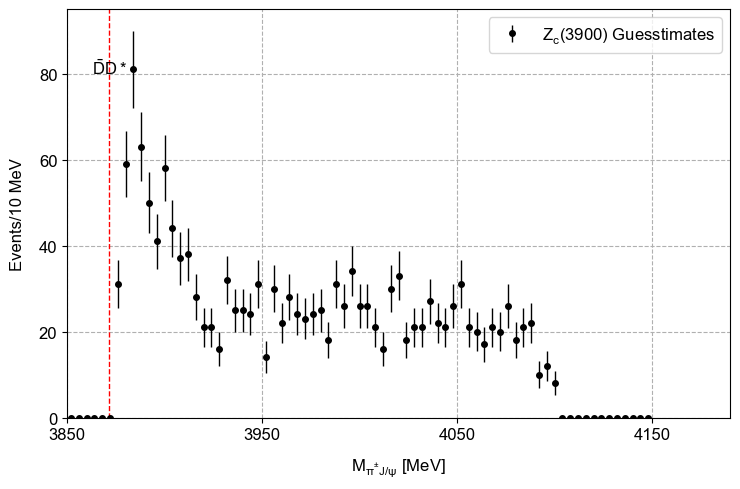

In [4]:
# Load the data
Zc3900_data = pd.read_csv('Zc3900_D0Dbarstar.csv')
invmass = Zc3900_data['invmass[MeV]']
invmass_low = Zc3900_data['Invmass_low[MeV]']
invmass_high = Zc3900_data['Invmass_high[MeV]']
weighted_candidates = Zc3900_data['Events']
upper_err = np.abs(Zc3900_data['y_err']) # Ensure non-negative
lower_err = np.abs(Zc3900_data['y_err'])  # Ensure non-negative

# Function to generate random energy points
def gen_Eaxis():
    x_data = []
    for i in range(len(invmass)):
        x_val = random.uniform(invmass_low[i], invmass_high[i])
        x_data.append(x_val)
    return x_data

# Define region of interest
energy_low = 3850
energy_high = 4190

# Generate x values
x_vals = gen_Eaxis()

# Set font to Arial and enable mathtext
# plt.rc('text', usetex=True)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.default'] = 'regular'

# Plotting
plt.figure(figsize=(7.5,5))

# Scatter plot with asymmetric error bars
plt.errorbar(invmass, weighted_candidates,
             yerr=[lower_err, upper_err], fmt='o',
             color='black', ecolor='black', elinewidth=1.0, markersize = 4.0, capsize=0.0, label='$Z_c(3900)$ Guesstimates')

plt.axvline(T2*hbarc , color='red', linestyle='--', linewidth=1.0)
plt.text(T2*hbarc, 80, r'$\bar{D} D*$', color='k', fontsize= 12, ha='center')
plt.xlabel(r'$M_{ \pi^{\pm} J/\psi}$ [MeV]', fontsize = 12, labelpad=10)
plt.ylabel('Events/10 MeV', fontsize = 12, labelpad=10)
plt.xlim(energy_low, energy_high)
plt.ylim(0, 95)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xticks(np.arange(energy_low, energy_high, 100), fontsize = 12)
plt.yticks((0.0, 20, 40, 60, 80), fontsize = 12)
plt.grid(True,linestyle='--')
plt.tight_layout()
plt.show()


In [5]:
class unif_pole:
    def __init__(self, RS, Ereal, Eimag):
        # RS is the two-channel Reimann sheet location of the pole
        # Use [1,-1] for bt, [-1,-1] for bb and [-1,1] for tb
        # Ereal is the real part of energy pole
        # Eimag is the imag part of energy pole

        if RS==[1,1]:
            print('Nice try. We do not violate causality here.')
            
        self.Eimag = Eimag
        self.RS  = RS
        Epole = Ereal - (1j)*Eimag
        self.pos = Epole

        # Compute uniformized momentum pole
        # for channel 1 and channel 2
        k1pole = cm.sqrt((Epole/hbarc)**2-T1**2)
        k2pole = cm.sqrt((Epole/hbarc)**2-T2**2)

        # Riemann sheet assignment
        beta1  = RS[0]*abs(k1pole.imag)
        beta2  = RS[1]*abs(k2pole.imag)

        # Get the real part, we need to be consistent with signs
        alpha1 = -np.sign(beta1)*np.abs(k1pole.real)
        alpha2 = -np.sign(beta2)*np.abs(k2pole.real)

        # Just for counterchecking
        # signs of beta1 and beta2 should agree
        # with RS[0] and RS[1], respectively
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.beta1 = beta1
        self.beta2 = beta2

        # Construct pole channel momenta
        polep1 = (1j)*beta1 + alpha1
        polep2 = (1j)*beta2 + alpha2

        Delta = cm.sqrt(T2**2 - T1**2)
        self.Delta = Delta

        # Uniformization of the assigned pole
        omega_pole = (polep1 + polep2)/Delta
        recip_omg_pol = 1/omega_pole
        self.omega_pole = omega_pole
        self.recip_omg_pol = recip_omg_pol

        # Get pole regulator
        # for [bt] sheet
        if RS==[-1,1]:
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))
        # for [bb] sheet
        elif RS==[-1,-1]:
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))
        # for [tb] sheet
        elif RS==[1,-1]:
            omega_reg = np.abs(recip_omg_pol)*cm.exp(-0.5*np.pi*(1j))

        self.omega_reg = omega_reg
        self.recip_omg_reg = 1/omega_reg

        p1_reg = omega_reg + 1/omega_reg
        p2_reg = omega_reg - 1/omega_reg

        # Riemann sheet identifier for pole regulator
        def RSlabel(pimag1, pimag2):
            if pimag1>0 and pimag2>0:
                RS = 'tt' #sheet 1
            elif pimag1<0 and pimag2>0:
                RS = 'bt' #sheet 2
            elif pimag1<0 and pimag2<0:
                RS = 'bb' #sheet 3
            elif pimag1>0 and pimag2<0:
                RS = 'tb' #sheet 4
            return RS
        # If you want to check the Riemann sheet of pole regulator
        self.regulator = ['{:.2f}'.format(np.sqrt(p1_reg**2.0+T1**2.0)*hbarc), RSlabel(p1_reg.imag, p2_reg.imag)]
        self.assignedpole = ['{:.2f}'.format(np.sqrt(polep1**2.0+T1**2.0)*hbarc), RSlabel(polep1.imag, polep2.imag)]

    # The indent on this part is very important
    # Calculate the S-matrix contribution of the uniformized pole
    def smat11(self, Ecm):
        # Get channel momenta of Ecm
        p1 = np.sqrt((Ecm/hbarc)**2.0-T1**2.0)
        p2 = np.zeros([NEpoints,],dtype = 'complex')
        for pndx in range(len(Ecm)):
            p2_pts = cm.sqrt((Ecm[pndx]/hbarc)**2.0-T2**2.0)
            p2[pndx] = p2_pts

        # Get uniformized parameter
        omega = (p1 + p2)/self.Delta

        # Numerator of S-matrix
        Numpol = (omega-np.conj(self.recip_omg_pol))*(omega+self.recip_omg_pol)
        Numreg = (omega-np.conj(self.recip_omg_reg))*(omega+self.recip_omg_reg)
        Num = Numpol*Numreg

        # Denominator of S-matrix
        Denpol = (omega-self.omega_pole)*(omega+np.conj(self.omega_pole))
        Denreg = (omega-self.omega_reg)*(omega+np.conj(self.omega_reg))
        Den = Denpol*Denreg

        return np.abs((self.omega_pole*self.omega_reg))**2.0*Num/Den

    def smat22(self, Ecm):
        #Get channel momenta of Ecm
        p1 = np.sqrt((Ecm/hbarc)**2.0-T1**2.0)
        p2 = np.zeros([NEpoints,],dtype = 'complex')
        for pndx in range(len(Ecm)):
            p2_pts = cm.sqrt((Ecm[pndx]/hbarc)**2.0-T2**2.0)
            p2[pndx] = p2_pts

        #Get uniformized parameter
        omega = (p1 + p2)/self.Delta

        #Numerator of S-matrix
        Numpol = (omega+np.conj(self.recip_omg_pol))*(omega-self.recip_omg_pol)
        Numreg = (omega+np.conj(self.recip_omg_reg))*(omega-self.recip_omg_reg)
        Num = Numpol*Numreg
        #Denominator of S-matrix

        Denpol = (omega-self.omega_pole)*(omega+np.conj(self.omega_pole))
        Denreg = (omega-self.omega_reg)*(omega+np.conj(self.omega_reg))
        Den = Denpol*Denreg

        return np.abs((self.omega_pole*self.omega_reg))**2.0*Num/Den

    def smatdet(self, Ecm):
        #Get channel momenta of Ecm
        p1 = np.sqrt((Ecm/hbarc)**2.0-T1**2.0)
        p2 = np.zeros([NEpoints,],dtype = 'complex')
        for pndx in range(len(Ecm)):
            p2_pts = cm.sqrt((Ecm[pndx]/197.3)**2.0-T2**2.0)
            p2[pndx] = p2_pts

        #Get uniformized parameter
        omega = (p1 + p2)/self.Delta

        #Numerator of S-matrix
        Numpol = (omega-np.conj(self.omega_pole))*(omega+self.omega_pole)
        Numreg = (omega-np.conj(self.omega_reg))*(omega+self.omega_reg)
        Num = Numpol*Numreg

        #Denominator of S-matrix
        Denpol = (omega-self.omega_pole)*(omega+np.conj(self.omega_pole))
        Denreg = (omega-self.omega_reg)*(omega+np.conj(self.omega_reg))
        Den = Denpol*Denreg

        return np.abs((self.omega_pole*self.omega_reg))**2.0*Num/Den

In [6]:
def detect_cusp(input_array, threshold=0.1):
    # Calculate the derivative of the real and imaginary parts
    real_diff = np.diff(np.real(input_array))
    imag_diff = np.diff(np.imag(input_array))

    # Detect points where the real part has a cusp
    real_cusp_indices = np.where(np.abs(real_diff) > threshold)[0] + 1

    # Detect points where the imaginary part has a cusp
    imag_cusp_indices = np.where(np.abs(imag_diff) > threshold)[0] + 1

    # Combine the indices and remove duplicates
    all_cusp_indices = np.unique(np.concatenate((real_cusp_indices, imag_cusp_indices)))

    # Modify the array by negating the sign for both real and imaginary parts
    for cusp_index in all_cusp_indices:
        input_array[cusp_index:] = -input_array[cusp_index:]

    return input_array

Create ```skip_duplicate()``` function to avoid possible duplication of poles in the same Riemann sheet.

In [7]:
def skip_duplicate(real1, imag1, Nreal, Nimag):
    # Create lists of available real and imag values
    real_list = [entry for entry in range(1, Nreal) if entry != real1]
    imag_list = [entry for entry in range(1, Nimag) if entry != imag1]

    # Randomly choose real values without duplication
    real_choices = np.random.choice(real_list, 10, replace=False)
    # Randomly choose imag values without duplication
    imag_choices = np.random.choice(imag_list, 10, replace=False)
    # Set the list size to the desired number of relevant and BG poles
    # We anticipate 4 relevant poles and 6 BG. That is 10.

    # Combine real and imag values into two lists
    real_values = [real1] + list(real_choices)
    imag_values = [imag1] + list(imag_choices)

    indx = [real_values, imag_values]
    return indx

###  Add phase space and background

We create a function ```dalitz()``` to generate the Dalitz plot in which the phase space shall be obtained.

We also create a function ```polynom()``` to randomly generate an nth degree polynomial to be added as background.

In [8]:
import numpy as np

def ddstar_phase_space(m_inv_ddstar):
    # 1. Convert input to a NumPy array to handle scalars, lists, or arrays
    m_inv_ddstar = np.asarray(m_inv_ddstar)/1000
    
    def kallen(x, y, z):
        lam = x**2 + y**2 + z**2 - 2*x*y - 2*x*z - 2*y*z
        # This is already vectorized!
        return np.where(lam <= 0, 0, lam)

    # Physical Constants
    M = 4.260      # Mass of Y(4260)
    mD = 1.8648    # Mass of D meson
    mDst = 2.0063  # Mass of D* meson
    m_pi = 0.13957 # Mass of bachelor pion
    threshold = mD + mDst
    
    s1 = m_inv_ddstar**2
    
    # 2. Calculate momenta using the vectorized kallen function
    # Note: we use np.maximum to avoid division by zero if m_inv is 0
    p_star = np.sqrt(kallen(s1, mD**2, mDst**2)) / (2 * np.maximum(m_inv_ddstar, 1e-9))
    p_bachelor = np.sqrt(kallen(M**2, s1, m_pi**2)) / (2 * M)
    
    # 3. Use np.where to handle the threshold condition for the whole array
    phase_space = p_star * p_bachelor / M
    return np.where(m_inv_ddstar < threshold, 0.0, phase_space)

In [9]:
g = ddstar_phase_space(x_vals)

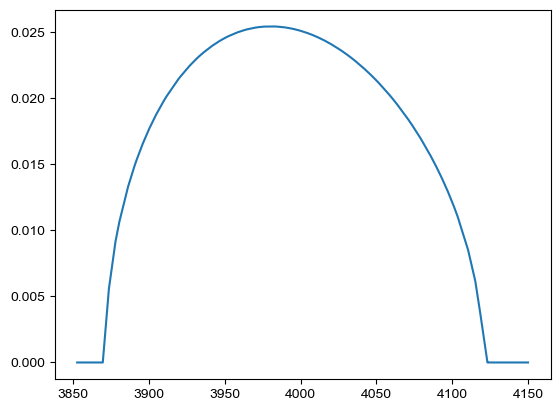

In [10]:
plt.plot(x_vals,g)

Fit Values:
<ValueView a=7124.652402775101 b=-0.0016056026551119753 c=-6287.958430602658 d=-197.62356358002916>

Fit Errors:
<ErrorView a=26.9193167215858 b=0.0002477632083537386 c=7.320483813417013 d=6.5445426520948615>


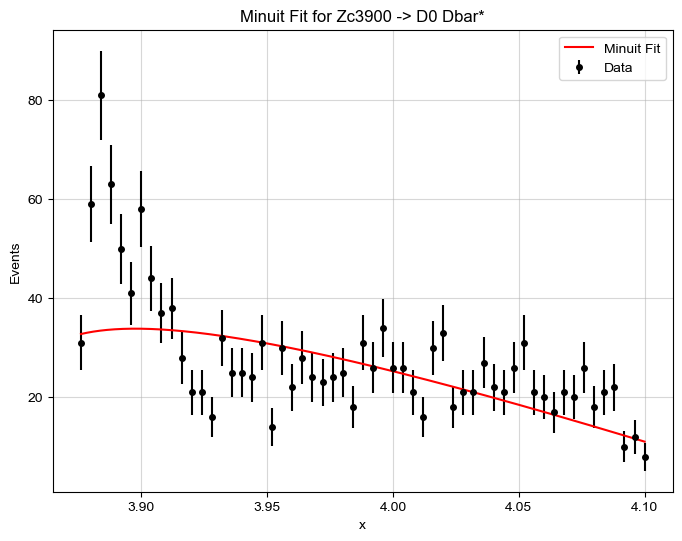

In [11]:
import pandas as pd
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("Zc3900_D0Dbarstar.csv")

# Filter out bins with zero error to avoid division by zero during the fit
mask = df['y_err'] > 0
x_data = df.loc[mask, 'x'].values
y_data = df.loc[mask, 'Events'].values
y_err = df.loc[mask, 'y_err'].values

# 2. Define the fitting function
def bk(x, a, b, c, d):
    return a / (x - 3.840)**b + c + d * x

# 3. Create a LeastSquares cost function
# LeastSquares takes x, y, y_error and the model function
least_squares = LeastSquares(x_data, y_data, y_err, bk)

# 4. Initialize Minuit with starting values
# We initialize the parameters in the middle of your provided bounds
m = Minuit(least_squares, a=7500, b=-0.005, c=-6200, d=-200)

# 5. Set the parameter limits based on your specifications
m.limits['a'] = (7000, 8000)
m.limits['b'] = (-0.009, -0.001)
m.limits['c'] = (-6300, -6100)
m.limits['d'] = (-250, -150)

# 6. Perform the minimization
m.migrad()  # Finds minimum
m.hesse()   # Computes errors

# Print the fit results
print("Fit Values:")
print(m.values)
print("\nFit Errors:")
print(m.errors)

# 7. Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', label='Data', markersize=4)

# Generate a smooth line for the fit using the best fit parameters
x_fit = np.linspace(min(x_data), max(x_data), 500)
y_fit = bk(x_fit, *m.values)
plt.plot(x_fit, y_fit, color='red', label='Minuit Fit')

plt.xlabel('x')
plt.ylabel('Events')
plt.title('Minuit Fit for Zc3900 -> D0 Dbar*')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Fit Values:
<ValueView a=7323.403919553659 b=-0.004480443495921923 c=-6239.722337205933 d=-249.9992918195784>

Fit Errors:
<ErrorView a=652.6807215611043 b=0.000515778871521576 c=157.37210762236828 d=22.559688913261482>


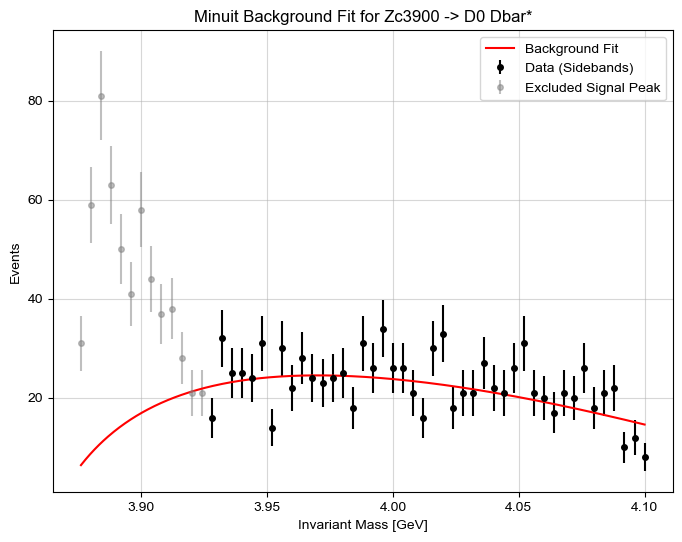

In [13]:
import pandas as pd
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("Zc3900_D0Dbarstar.csv")

# Define the boundaries for the peak signal to be excluded 
# The Zc(3900) peak roughly falls between 3.875 and 3.925 GeV in this dataset
signal_min = 3.875
signal_max = 3.925

# Filter out bins with zero error to avoid division by zero 
# AND exclude the signal region from the fit data
mask = (df['y_err'] > 0) & ((df['x'] < signal_min) | (df['x'] > signal_max))
x_data = df.loc[mask, 'x'].values
y_data = df.loc[mask, 'Events'].values
y_err = df.loc[mask, 'y_err'].values

# 2. Define the fitting function
def bk(x, a, b, c, d):
    return a / (x - 3.840)**b + c + d * x

# 3. Create a LeastSquares cost function
# LeastSquares takes x, y, y_error and the model function
least_squares = LeastSquares(x_data, y_data, y_err, bk)

# 4. Initialize Minuit with starting values
# We initialize the parameters in the middle of your provided bounds
m = Minuit(least_squares, a=7500, b=-0.005, c=-6200, d=-200)

# 5. Set the parameter limits based on your specifications
m.limits['a'] = (7000, 8000)
m.limits['b'] = (-0.009, -0.001)
m.limits['c'] = (-6300, -6100)
m.limits['d'] = (-250, -150)

# 6. Perform the minimization
m.migrad()  # Finds minimum
m.hesse()   # Computes errors

# Print the fit results
print("Fit Values:")
print(m.values)
print("\nFit Errors:")
print(m.errors)

# 7. Plot the data and the fit
plt.figure(figsize=(8, 6))

# Plot the background data (used in the fit)
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', label='Data (Sidebands)', markersize=4)

# Get and plot the excluded peak signal data for visualization
mask_excluded = (df['y_err'] > 0) & (df['x'] >= signal_min) & (df['x'] <= signal_max)
x_excl = df.loc[mask_excluded, 'x'].values
y_excl = df.loc[mask_excluded, 'Events'].values
y_err_excl = df.loc[mask_excluded, 'y_err'].values

plt.errorbar(x_excl, y_excl, yerr=y_err_excl, fmt='o', color='gray', alpha=0.5, label='Excluded Signal Peak', markersize=4)

# Generate a smooth line for the fit using the best fit parameters across the ENTIRE range
# (Extract the min and max from the whole dataset where errors > 0 to plot smoothly over the peak)
x_min, x_max = df.loc[df['y_err'] > 0, 'x'].min(), df.loc[df['y_err'] > 0, 'x'].max()
x_fit = np.linspace(x_min, x_max, 500)
y_fit = bk(x_fit, *m.values)

plt.plot(x_fit, y_fit, color='red', label='Background Fit')

plt.xlabel('Invariant Mass [GeV]')
plt.ylabel('Events')
plt.title('Minuit Background Fit for Zc3900 -> D0 Dbar*')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()